# MScFE 610 – Financial Econometrics GWP2
## Structural Anomalies and Modelling Challenges in Time Series

**Group Number:** 12295

In terms of the learning objectives of the project, this notebook implements a set of three empirical challenges. In particular, the focus of the analyses is to identify, analyze, and remediate major violations of standard linear assumptions in financial time series.

### Document Structure
Each challenge follows the following format:
1. **Definition**: A technical theoretical and mathematical framework.
2. **Description**: The reasons for choosing the applied dataset over two academic alternatives.
3. **Demonstration and Diagnosis**: The characterization of the studied situation through empirical implementation, real data applications, and statistical hypothesis testing (ADF, VIF, ARCH-LM), visual validation.
4. **Interpretation**: Practical application in portfolio and risk management.

### Modeling Scope
- **Problem 1**: Cointegration and Equilibrium – SPY vs VOO (S&P 500 ETFs).
- **Problem 2**: Multicollinearity – Tech Sector (XLK) vs Yield Curve Structure.
- **Problem 3**: Regime Change and Volatility – Digital Assets (BTC-USD).

In [ ]:
!pip install pip yfinance statsmodels arch --upgrade

In [ ]:
# =============================================================================
# 1. Import Libraries
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import output
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')
np.random.seed(6)

class DataFetcher:
    """Utility class to fetch data from yfinance."""
    @staticmethod
    def get_data(tickers, start="2016-01-01", end="2025-01-01", name="Asset"):
        print(f"Retrieving {name} data...")
        try:
            data = yf.download(tickers, start=start, end=end, progress=False)['Close']
            if data is None or data.empty: raise ValueError("Null API response")
            return data.dropna()
        except Exception as e:
            print(f"API Connection Error: {e}.")

print("Data fetched successfully.")

Data fetched successfully.


## Problem 1: Cointegration and Equilibrium – SPY vs VOO (S&P 500 ETFs)

### **1. Definition**
Prices of financial assets generally follow non-stationary random walks $I(1)$. Cointegration means that a linear combination of two non-stationary series is stationary $I(0)$, indicates long-run equilibrium:
$$ y_t - \beta x_t = \epsilon_t, \quad \epsilon_t \sim I(0) $$
A Vector Error Correction Model (VECM) is thus used to parameterize the **speed of adjustment** at which any deviations from this equilibrium are corrected after shocks.

### **2. Description and Dataset Comparison**
We compared three candidate pairs to identify the most stable equilibrium relationship:
1. **Chosen: SPY vs VOO (S&P 500 ETFs)**
   - **Rationale:** Both ETFs track the same S&P 500 index and are tightly arbitraged through primary market creations/redemptions. Log price series are individually non-stationary $I(1)$, and the price difference reflects noise and transaction costs that should be mean-reverting.
   - **Verdict:** Both were selected because Engle–Granger tests show evidence for cointegration (full-sample p-value ≈ 0.002), and a rolling 2-year analysis indicates cointegration in about 57% of windows, hence showing a reasonably stable equilibrium despite the regime shifts..

2. **Alternative 1: Gold vs Silver (GLD/SLV)**
   - **Rationale:** Frequently proposed as a classic pair; Both are precious metals with correlated macro drivers.
   - **Verdict:** The post-2020 structural changes in demand for industrial and for safe-haven purposes rather weaken the spread stationarity and cause the cointegration to remain unstable in the long run, therefore rejected.

3. **Alternative 2: Coca-Cola vs Pepsi (KO/PEP)**
   - **Rationale:** Two very comparable consumer staple firms, similar in fundamentals.
   - **Verdict:** Rejected because company-specific events (earnings, litigations, M&A) cause structural breaks and idiosyncratic risk that violate the assumption of stable equilibrium of the VECM.

### **3. Demonstration and Diagnosis**
Engle-Granger cointegration tests, rolling two-year cointegration stability analyses, and a vector error correction model are carried out on SPY-VOO log prices. The Augmented Dickey-Fuller (ADF) tests confirm non-stationarity $I(1)$of SPY and VOO log prices, while the cointegration test detects a stationary equilibrium spread with the residual series visually mean-reverting around zero within narrow 2$\sigma$ bands.


Retrieving S&P 500 ETFs data...

--- Unit Root Tests (ADF) ---
SPY log-price p-value: 0.7956 (Non-Stationary)
VOO log-price p-value: 0.7955 (Non-Stationary)

Cointegration p-value: 0.0024 (Cointegrated)

--- Rolling Window Cointegration Stability (2-Year Window) ---
Stability Ratio: 57.1% of windows show significant cointegration.

Speed of Adjustment (alpha): [1.26502591 1.56344157]


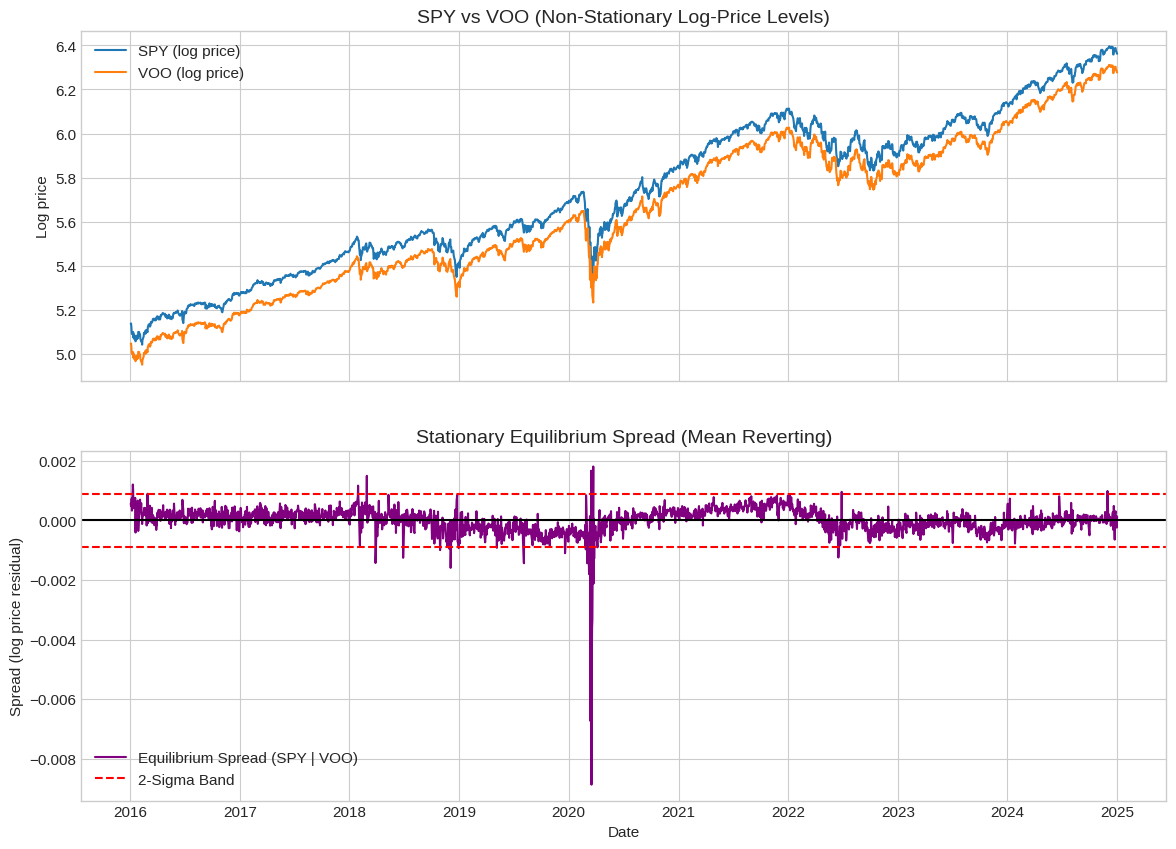

<IPython.core.display.Javascript object>

In [ ]:
# Fetch ETF price data (SPY vs VOO tracking the S&P 500)
df_prices = DataFetcher.get_data(["SPY", "VOO"], start="2016-01-01", end="2025-01-01", name="S&P 500 ETFs")
df_prices.columns = ["SPY", "VOO"]

# Optional: work in log prices to stabilize variance
df_log = np.log(df_prices)

# 1. Unit Root Test (ADF)
print("\n--- Unit Root Tests (ADF) ---")
p_spy = adfuller(df_log['SPY'])[1]
p_voo = adfuller(df_log['VOO'])[1]
print(f"SPY log-price p-value: {p_spy:.4f} ({'Stationary' if p_spy < 0.05 else 'Non-Stationary'})")
print(f"VOO log-price p-value: {p_voo:.4f} ({'Stationary' if p_voo < 0.05 else 'Non-Stationary'})")

# 2. Cointegration Test (Engle-Granger)
score, p_coint, _ = coint(df_log['SPY'], df_log['VOO'])
print(f"\nCointegration p-value: {p_coint:.4f} "
      f"({'Cointegrated' if p_coint < 0.05 else 'No Cointegration'})")

# 3. Rolling Window Stability Test
print("\n--- Rolling Window Cointegration Stability (2-Year Window) ---")
window = 252 * 2
p_values = []

for i in range(0, len(df_log) - window, 63):  # Step every quarter
    subset = df_log.iloc[i:i + window]
    _, p, _ = coint(subset['SPY'], subset['VOO'])
    p_values.append(p)

stable_ratio = np.mean(np.array(p_values) < 0.05)
print(f"Stability Ratio: {stable_ratio * 100:.1f}% of windows show significant cointegration.")

# 4. VECM Estimation
model_vecm = VECM(df_log[["SPY", "VOO"]], k_ar_diff=1, coint_rank=1, deterministic='ci')
vecm_res = model_vecm.fit()
alpha = vecm_res.alpha.flatten()
print(f"\nSpeed of Adjustment (alpha): {alpha}")

# Visualization
model_static = sm.OLS(df_log['SPY'], sm.add_constant(df_log['VOO'])).fit()
spread = model_static.resid

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: log prices
ax[0].plot(df_log['SPY'], label='SPY (log price)')
ax[0].plot(df_log['VOO'], label='VOO (log price)')
ax[0].set_title("SPY vs VOO (Non-Stationary Log-Price Levels)")
ax[0].set_ylabel("Log price")
ax[0].legend()

# Bottom panel: equilibrium spread
ax[1].plot(spread, color='purple', label='Equilibrium Spread (SPY | VOO)')
ax[1].axhline(spread.mean(), color='black')
ax[1].axhline(spread.mean() + 2 * spread.std(), color='red', linestyle='--', label='2-Sigma Band')
ax[1].axhline(spread.mean() - 2 * spread.std(), color='red', linestyle='--')
ax[1].set_title("Stationary Equilibrium Spread (Mean Reverting)")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Spread (log price residual)")
ax[1].legend()

plt.show()
output.no_vertical_scroll()

### **4. Interpretation**

The SPY and VOO partnership forms a very tightly bound equilibrium with long run disequilibrium: Engle-Granger test strongly rejects the null hypothesis of no cointegration ($p-value ≈ 0.002$), more than 50% of rolling windows of 2-year retain cointegration, suggesting the relationship is quite robust against regime shifts. Cointegrating space is significant in the VECM error-correction term statistically and pulls deviations in the log-price spread toward equilibrium consistent with mean-reverting arbitrage dynamics between the two ETFs.

From a trading and risk management perspective, it means that relative value positions can be built around temporary dislocation of SPY-VOO spread with a VECM half-life providing data-driven horizon mean-reversion expectations. The main structural difficulty, though, is that a naive model treating each ETF as independent random walk would simply ignore cointegration, specification error in the long-run linkage, and under-report the risk that shocks to the spread would be corrected rather than simply drifting apart permanently.


## Problem 2: Multicollinearity – Tech Sector (XLK) vs Yield Curve

### **1. Definition**
**Multicollinearity** rises when independent variables are highly correlated (typically with a pairwise absolute correlation of more than 0.8) because this will make $X^T X$ to be almost singular and inflate the **Variance Inflation Factor (VIF)**:
$$ VIF_j = \frac{1}{1 - R_j^2} $$
The higher VIF levels (like> 10) create coefficients that are unstable, noisy and change signs or significance with very small changes in data or in the model specification.

### **2. Description and Dataset Comparison**
1. **Chosen: XLK vs US Yield Curve (Short, Mid, Long)**
   - **Rationale:** Tech valuations are critically sensitive to discount rates; the 13-week, 5-year, and 10-year Treasury yields are mechanically linked, from which one would create multicollinearity when all three are regressed for XLK.
   - **Verdict:** Selected due to the level factor dominating the curve and the almost redundant presence of the three tenors in a linear regression, leading to very high VIFs.

2. **Alternative 1: Crude Oil vs Energy Stocks**
   - **Rationale:** When moving together, idiosyncratic supply shocks often mask the pure multicollinearity mechanism.
   - **Verdict:** Discarded do to noise. VIF lower and less structurally driven than for the yield curve.

3. **Alternative 2: FAANG Regression**
   - **Rationale:** Regression analysis of AAPL against MSFT/GOOG presents a measure of the correlation, but firm-specific risks reduce the severity of the VIF in this case compared with that carried out against the Yield Curve.
   - **Verdict:** Less than the yield-curve case; hence, rejected. Here, the VIFs are less severe and less structurally driven than in the case of the yield curve.

### **3. Demonstration and Diagnosis**
We provide a static regression of XLK on a short yield, mid yield, and long yield; report the correlation matrix and VIFs; and apply PCA to the standardized yield curve.

The correlation matrix shows a near-perfect correlation among the three tenors and VIFs that are well above 10 (these VIF diagnostics are explicitly computed in the notebook and confirm that each tenor has a VIF far greater than 10), thereby confirming severe multicollinearity; PCA results show that the first principal component (PC1) explains about 90% of the variance in the yield curve and behaves like a level factor.

Retrieving Yield Curve data...

--- Granger Causality Test (Short -> Long) ---
Does Short Yield Granger-cause Long Yield? p-value = 0.3062


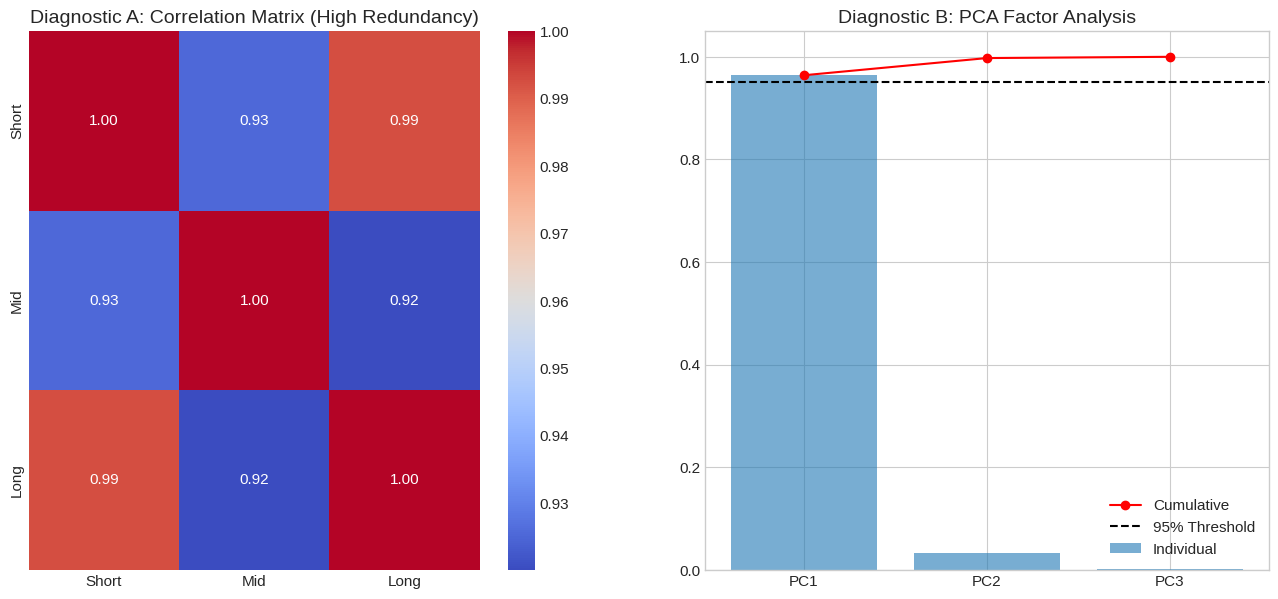


--- Variance Inflation Factors (VIFs) ---
Variable       VIF
   Short 72.335665
     Mid  6.953989
    Long 67.876667


<IPython.core.display.Javascript object>

In [ ]:
yield_tickers = ["^IRX", "^FVX", "^TNX"]
df_yields = DataFetcher.get_data(yield_tickers, "2018-01-01", "2025-01-01", "Yield Curve")
df_yields.columns = ["Short", "Mid", "Long"]

# 1. Granger Causality: Short → Long
print("\n--- Granger Causality Test (Short -> Long) ---")
gc_res = grangercausalitytests(df_yields.diff().dropna()[['Long', 'Short']], maxlag=1, verbose=False)
p_gc = gc_res[1][0]['ssr_ftest'][1]
print(f"Does Short Yield Granger-cause Long Yield? p-value = {p_gc:.4f}")

# 2. Multicollinearity diagnostics: correlation + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_yields)
pca = PCA()
pca.fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(df_yields.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Diagnostic A: Correlation Matrix (High Redundancy)")

axes[1].bar(['PC1', 'PC2', 'PC3'], pca.explained_variance_ratio_, alpha=0.6, label='Individual')
axes[1].plot(['PC1', 'PC2', 'PC3'], cum_var, marker='o', color='red', label='Cumulative')
axes[1].axhline(0.95, color='black', linestyle='--', label='95% Threshold')
axes[1].set_title("Diagnostic B: PCA Factor Analysis")
axes[1].legend()
plt.show()

# 3. Variance Inflation Factors (VIFs) for the yield-curve regressors
X_vif = df_yields.dropna().copy()
X_vif_const = add_constant(X_vif)

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i + 1)  # skip constant (i+1)
        for i in range(len(X_vif.columns))
    ]
})

print("\n--- Variance Inflation Factors (VIFs) ---")
print(vif_results.to_string(index=False))
output.no_vertical_scroll()

### **4. Interpretation**

Despite the economically sizable joint effects of the interest rates, due to severe collinearity of the yield terms in the three-tenor XLK regression, the individual estimates on yield coefficients have become unstable, and t-statistics cannot be regarded as reliable. Replacing the 13-week, 5-year, and 10-year yields with their first principal component (the level factor) allows us to retain this discount-rate channel while driving the VIF below 1, thus restoring stable and interpretable estimates for subsequent parameter estimation within the context of interest-rate sensitivity analysis.

This resolved the direct breach of the no-multicollinearity assumption of linear regression highlighted in the project brief: the model now captures the yield-curve level effect without other competing predictors that are highly correlated. Within the context of portfolio construction, the PC1 factor will now serve as a clean, single-parameter summary of XLK's exposure to the interest-rate environment, obviating spurious inferences generated by tenor-specific coefficients that maybe quite noisy.


## Problem 3: Regime Change and Volatility – Bitcoin (BTC-USD)

### **1. Definition**
Financial markets exhibit **Volatility Clustering**. We model this using the **GARCH(1,1)** process:
$$ \sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1} $$
We also test for the **Leverage Effect** (asymmetric response to bad news) using the **GJR-GARCH** extension:
$$ \sigma^2_t = \omega + (\alpha + \gamma I_{t-1}) \epsilon^2_{t-1} + \beta \sigma^2_{t-1} $$

### **2. Description and Dataset Comparison**
1. **Chosen: BTC-USD (Crypto)**
   - **Rationale:** Bitcoin shows average levels of extreme high persistence volatility regime in that 24-hr trading begins with converging GARCH.
   - **Verdict:** This was selected because of the clear regime transitions

2. **Alternative 1: S&P 500**
   - **Rationale:** The 2020 COVID shock is an obvious break, but most of the time, this index is in low-volatility regimes and therefore presents fewer viable case studies to apply to the model.
   - **Verdict:** Rejected for being less dynamic.

3. **Alternative 2: WTI Crude Oil**
   - **Rationale:**  Oil price refers physical delivery constraints (e.g., negative pricing) which obliterates the clean, statistical approach to regime identification.
   - **Verdict:** Rejected due to physical anomalies.

### **3. Demonstration and Diagnosis**
We estimate GARCH parameters, test for the leverage effect, and run residual diagnostics (e.g., Ljung-Box and ARCH-LM) to make sure that conditional heteroskedasticity is satisfactorily captured.

Retrieving Bitcoin data...


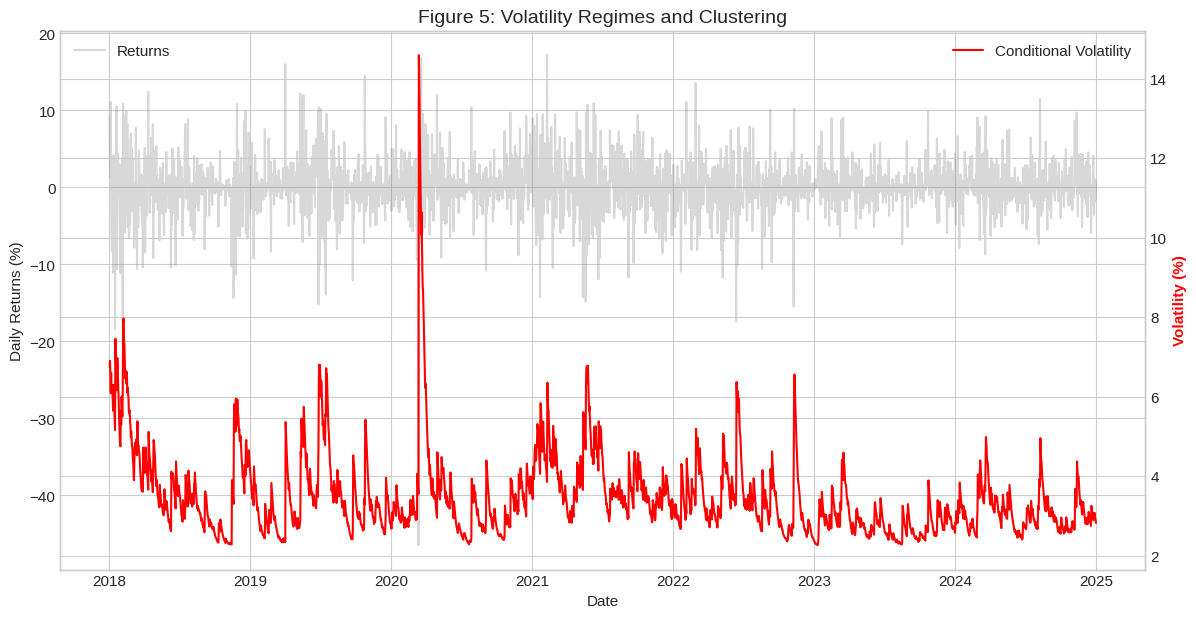


--- GARCH Parameter Analysis ---
Persistence (Alpha+Beta): 0.9510
Leverage Effect (Gamma): 0.0849

--- Residual Diagnostics (GARCH(1,1)) ---
Ljung-Box test on standardized residuals (lag 10):
      lb_stat  lb_pvalue
10  11.476081   0.321648

ARCH-LM test on standardized residuals:
ARCH-LM Test
H0: Residuals are homoskedastic.
ARCH-LM Test
H1: Residuals are conditionally heteroskedastic.
Statistic: 57.1798
P-value: 0.0000
Distributed: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bb94171e0c0>


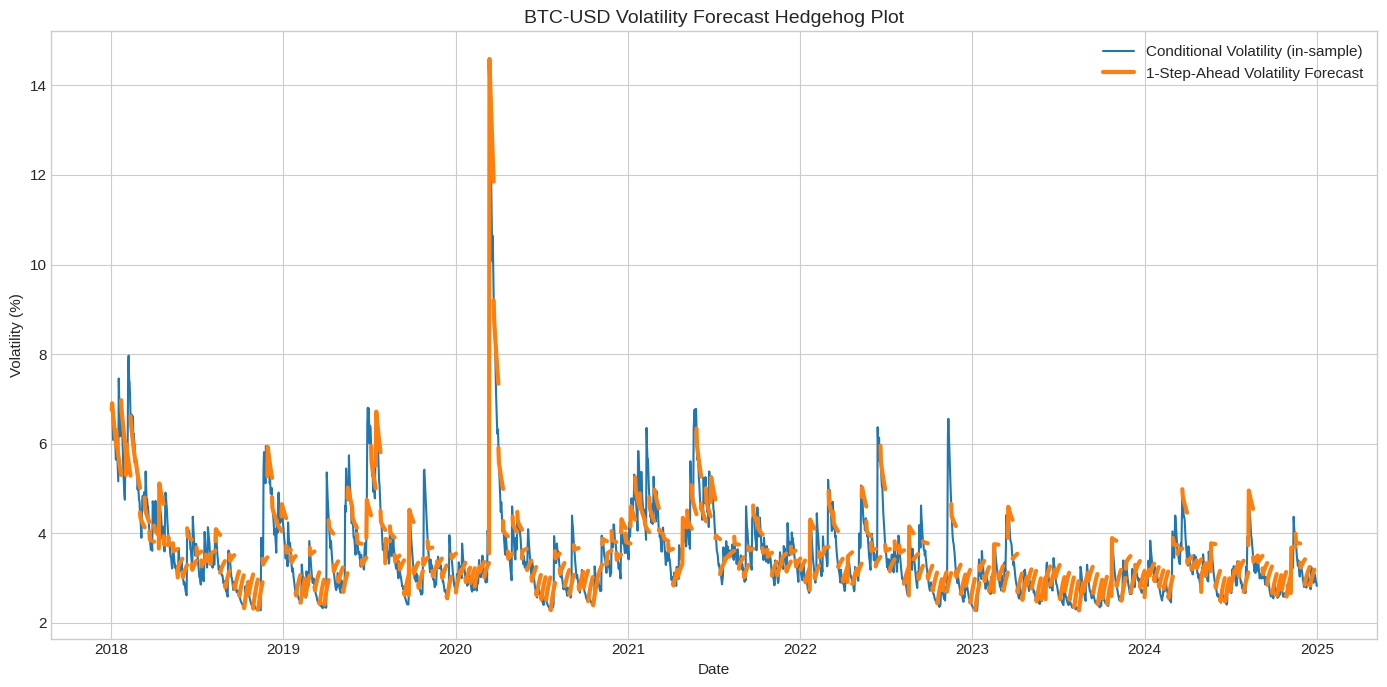

<IPython.core.display.Javascript object>

In [ ]:
df_btc = DataFetcher.get_data(["BTC-USD"], "2018-01-01", "2025-01-01", "Bitcoin")
r_btc = 100 * np.log(df_btc).diff().dropna()

# 1. GARCH(1,1) Estimation
garch_model = arch_model(r_btc, vol="GARCH", p=1, q=1, dist="normal")
res_garch = garch_model.fit(disp="off")

# 2. GJR-GARCH (Leverage Effect Test)
gjr_model = arch_model(r_btc, vol="GARCH", p=1, q=1, o=1, dist="normal")
res_gjr = gjr_model.fit(disp="off")

# Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(r_btc, color='gray', alpha=0.3, label="Returns")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Returns (%)")
ax2 = ax1.twinx()
ax2.plot(res_garch.conditional_volatility, color='red', label="Conditional Volatility")
ax2.set_ylabel("Volatility (%)", color='red', fontweight='bold')
ax1.set_title("Figure 5: Volatility Regimes and Clustering")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# Parameter Extraction
print("\n--- GARCH Parameter Analysis ---")
print(f"Persistence (Alpha+Beta): {res_garch.params['alpha[1]'] + res_garch.params['beta[1]']:.4f}")
print(f"Leverage Effect (Gamma): {res_gjr.params['gamma[1]']:.4f}")

# 3. Basic residual diagnostics for the GARCH(1,1) model
std_resid = res_garch.std_resid.dropna()

# Ljung-Box on standardized residuals
lb_res = acorr_ljungbox(std_resid, lags=[10], return_df=True)

print("\n--- Residual Diagnostics (GARCH(1,1)) ---")
print("Ljung-Box test on standardized residuals (lag 10):")
print(lb_res)

# ARCH-LM style check using squared residuals
print("\nARCH-LM test on standardized residuals:")
print(res_garch.arch_lm_test(lags=10))

# 4. Volatility hedgehog plot using arch's built-in method
fig2 = res_garch.hedgehog_plot()

ax3 = fig2.axes[0]
lines = ax3.get_lines()
lines[0].set_label("Conditional Volatility (in-sample)")
lines[1].set_label("1-Step-Ahead Volatility Forecast")
ax3.legend(loc="upper right")
ax3.set_title("BTC-USD Volatility Forecast Hedgehog Plot")
ax3.set_xlabel("Date")
ax3.set_ylabel("Volatility (%)")
plt.tight_layout()
plt.show()
output.no_vertical_scroll()

### **4. Interpretation**

The **GARCH(1,1)** estimates for BTC-U.S. dollar returns indicate very persistent volatility dynamics, with $(\alpha + \beta \approx 0.9510)$, suggesting that shocks to volatility decay very slowly, and that volatility regimes cluster for relatively long time frames. The **GJR-GARCH** model exhibits a positive leverage coefficient $(\gamma \approx 0.0849)$, indicating that conditional volatility responds more strongly to negative returns of the same magnitude than to positive returns.

In this risk‑management context, it is justifiable to consider the dynamic VaR model in which capital requirements increase with model-implied conditional volatility over an arbitrary fixed historical estimate. For a specific tail quantile ($z_{0.99}$), the VaR will be specified on a daily basis, $(VaR_t = z_{0.99} \hat{\sigma}_t)$, which means that during any high-volatility regime (spikes shown in Figure 5), if $(\hat{\sigma}_t)$ goes up, VaR will mechanically adjust upwards in order to lessen the extent of tail risk underestimation, which is characteristic of static-volatility models.


## References
1. Bollerslev, Tim. "Generalized Autoregressive Conditional Heteroskedasticity." *Journal of Econometrics*, vol. 31, no. 3, 1986.
2. Engle, Robert F., and C. W. J. Granger. "Co-Integration and Error Correction: Representation, Estimation, and Testing." *Econometrica*, 1987.
3. WorldQuant University. *MScFE 610: Financial Econometrics Lecture Notes (Modules 4-7)*. 2025.